In [10]:
import numpy as np                  # Numerical computation library
import pickle                       # Load pickle result files
import matplotlib.pyplot as plt     # Plotting library
import torch                        # Handle tensor data
import src.utils.data_trans as data_trans  

# ===================== 2. Define key parameters and paths =====================
sample_index = 7  # Sample index
max_log = 4       # Parameter for denormalization (consistent with training)

# Organize result paths for all optimizers as a dictionary: {optimizer_name: file_path}
optimizer_paths = {
    'TV-0% Noise': f'experiment/complex/admt_tv_lr0.05_ts200_sigma10_lossl1_noisestd0_missing0_20260212_093051/obs_modelanddata_64_10_new/{sample_index}_results.pkl',
    'TV-5% Noise': f'experiment/complex/admt_tv_lr0.05_ts200_sigma10_lossl1_noisestd5_missing0_20260213_112525/obs_modelanddata_64_10_new/{sample_index}_results.pkl',
    'TV-10% Noise': f'experiment/complex/admt_tv_lr0.05_ts200_sigma10_lossl1_noisestd10_missing0_20260214_151959/obs_modelanddata_64_10_new/{sample_index}_results.pkl',
    'Tikhonov-0% Noise': f'experiment/complex/admt_l2_lr0.05_ts200_sigma10_lossl1_noisestd0_missing0_20260209_121436/obs_modelanddata_64_10_new/{sample_index}_results.pkl',
    'Tikhonov-5% Noise': f'experiment/complex/admt_l2_lr0.05_ts200_sigma10_lossl1_noisestd5_missing0_20260210_110916/obs_modelanddata_64_10_new/{sample_index}_results.pkl',
    'Tikhonov-10% Noise': f'experiment/complex/admt_l2_lr0.05_ts200_sigma10_lossl1_noisestd10_missing0_20260211_130355/obs_modelanddata_64_10_new/{sample_index}_results.pkl',
}
gt_path = 'dataset/Test_Data/MT_Data_Test/obs_modelanddata_64_10_new.npz'
ground_truth = np.load(gt_path)['sig_model'][sample_index,0,:,:]
ground_truth.shape
obs_data=np.load(gt_path)['obs_data'][sample_index,:,:,:]
ground_truth.shape

(64, 64)

In [11]:
def log_normalize_decode(x_norm, max_log, eps=1e-12):
    """
    Decode normalized values: restore [-1, 1] normalized tensor to raw resistivity [1, 10000].

    Reverse flow: [-1, 1] -> [0, 1] -> inverse log10 -> [1, 10000]

    Args:
        x_norm: Normalized input tensor in [-1, 1]
        max_log: Same global maximum used during encoding
        eps: Same epsilon as encoding, for inverse robustness
    Returns:
        x_original: Recovered raw resistivity tensor in [1, 10000]
    """
    # 1. Map [-1, 1] back to [0, 1]
    x_norm_01 = (x_norm + 1) / 2
    # 2. Inverse normalize: recover log10(raw resistivity)
    log_x_original = x_norm_01 * (max_log + eps)
    # 3. Inverse log10: recover raw resistivity
    x_original = np.pow(10, log_x_original)

    return 1 / x_original

In [13]:
# Dictionary to store total loss sequences per optimizer
optimizer_losses = {}
optimizer_ssim={}
optimizer_rmse={}
optimizer_results = {}
optimizer_obs={}
for opt_name, path in optimizer_paths.items():
    try:
        # Load pickle file
        with open(path, 'rb') as f:
            results = pickle.load(f)

        # Extract total loss sequence and handle data format (tensor -> numpy/float)
        final_results = results['final_results']
        total_loss = final_results['total_losses']
        ssim = final_results['ssim']
        rmse = final_results['rmse']
        max_log=4
        mu =log_normalize_decode(results['mu_list'][-1][0,0,...],max_log)
        # mu =log_normalize_decode(results['mu'][-1][0,...],max_log)

        if isinstance(total_loss[0], torch.Tensor):
            # If loss is tensor, extract values and convert to numpy
            loss_np = np.array([loss.item() for loss in total_loss])
            mu_np = np.array(mu)

            ssim_np = np.array([ssim.item() for ssim in ssim])
            rmse_np = np.array([rmse.item() for rmse in rmse])
        else:
            # If already float, convert directly to numpy
            loss_np = np.array(total_loss)
            mu_np = np.array(mu)
            ssim_np = np.array(ssim)
            rmse_np = np.array(rmse)
        optimizer_losses[opt_name] = loss_np
        optimizer_results[opt_name] = mu_np
        optimizer_ssim[opt_name] = ssim_np
        optimizer_rmse[opt_name] = rmse_np
        print(f"Successfully loaded {opt_name} loss data, length: {len(loss_np)}")

    except Exception as e:
        print(f"Failed to load {opt_name}: {e}")


Successfully loaded TV-0% Noise loss data, length: 200
Successfully loaded TV-5% Noise loss data, length: 200
Successfully loaded TV-10% Noise loss data, length: 200
Successfully loaded Tikhonov-0% Noise loss data, length: 200
Successfully loaded Tikhonov-5% Noise loss data, length: 200
Successfully loaded Tikhonov-10% Noise loss data, length: 200


In [14]:
mu_np.shape

(64, 64)

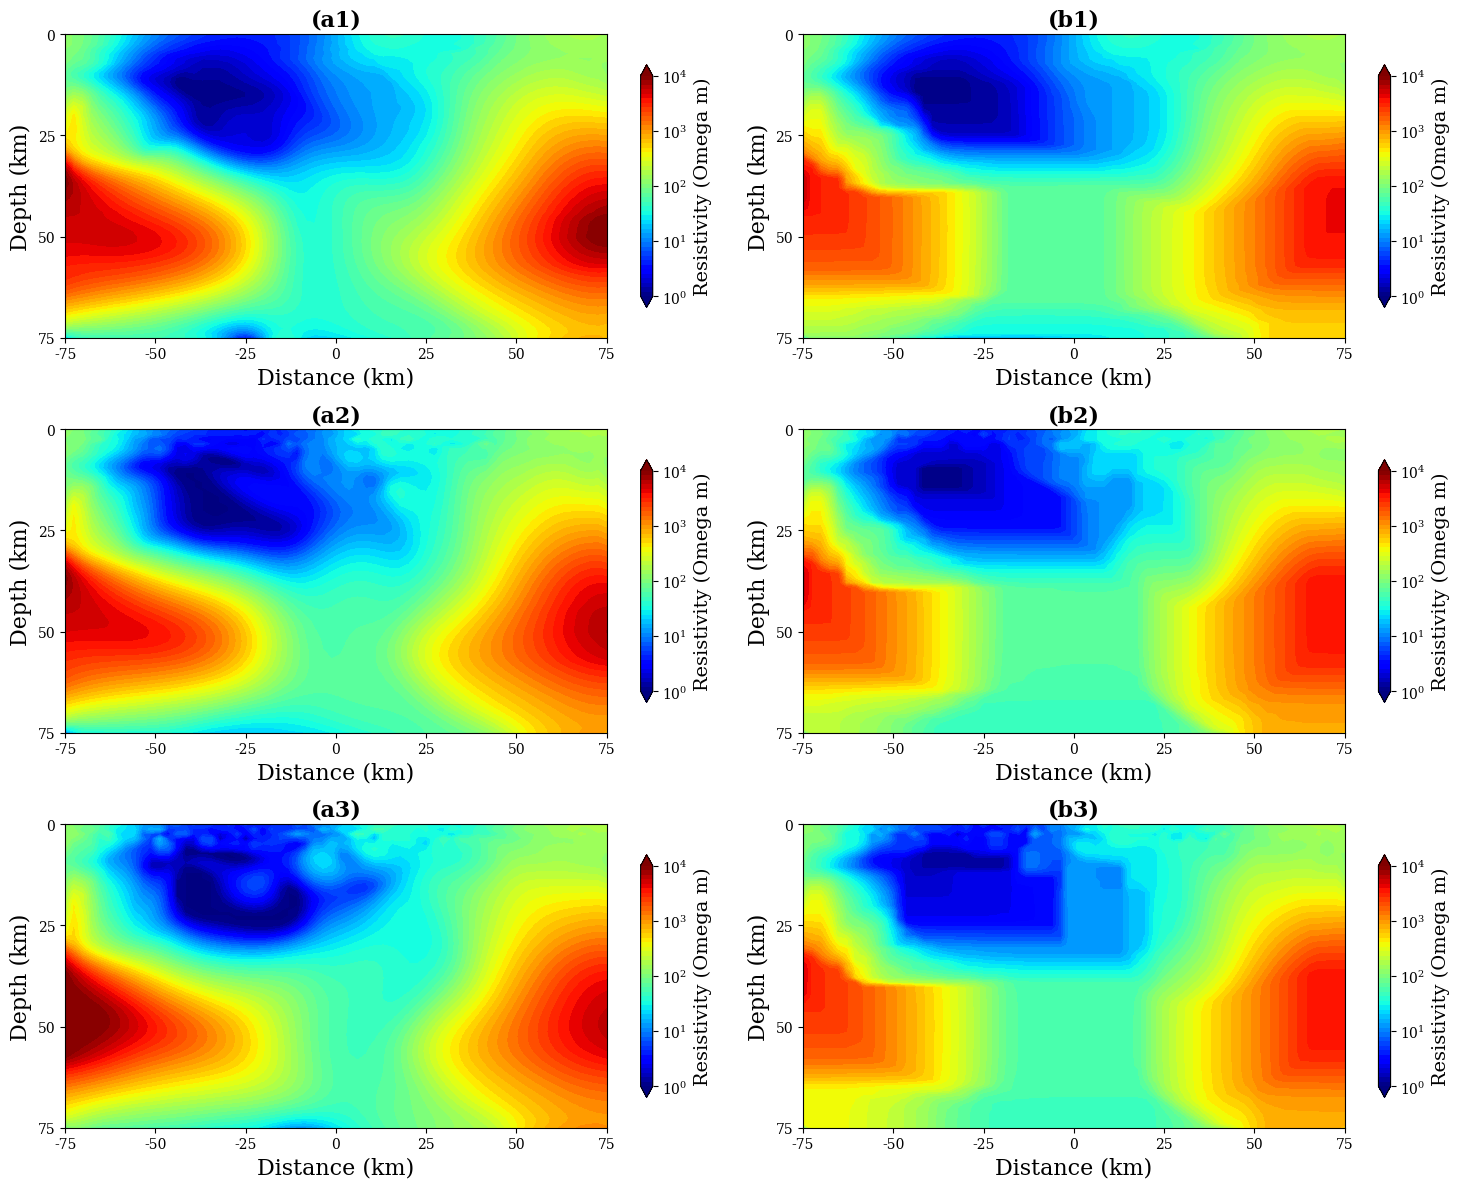

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

# ===================== Core: globally set Times New Roman font =====================
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'serif'
# ======================================================================

# ========== 1. Define plot order and subplot configuration ==========
plot_order = [
    'Tikhonov-0% Noise','TV-0% Noise', 'Tikhonov-5% Noise', 'TV-5% Noise', 'Tikhonov-10% Noise', 'TV-10% Noise'  
]
ssim_list=  ['Tikhonov-0% Noise','TV-0% Noise', 'Tikhonov-5% Noise', 'TV-5% Noise', 'Tikhonov-10% Noise', 'TV-10% Noise']
title_list=['(a1)','(b1)','(a2)','(b2)','(a3)','(b3)']  

# Set figure size
fig, axes = plt.subplots(3, 2,  figsize=(15, 12))
axes_flat = axes.flatten()

# ========== Core: define physical coordinate grid with tick labels ==========
# Step 1: Define tick positions ([-75,75] km and [0,75] km)
x_ticks = np.linspace(-75, 75, 7)  # x-axis ticks: [-75, -50, -25, 0, 25, 50, 75]
y_ticks = np.linspace(0, 75, 4)    # y-axis ticks: [0, 25, 50, 75]
# Step 2: Generate 64x64 physical coordinate grid
nx, ny = 64, 64
x_grid = np.linspace(x_ticks.min(), x_ticks.max(), nx)  # -75 to 75, 64 grid points
y_grid = np.linspace(y_ticks.min(), y_ticks.max(), ny)  # 0 to 75, 64 grid points
Y1, Z1 = np.meshgrid(x_grid, y_grid)  # Coordinate grid for contourf

# 50 contour levels, log spacing for uniform level distribution matching LogNorm
levels = np.logspace(np.log10(1e0), np.log10(1e4), 50)
# ========== 2. Iterate over each subplot ==========
for idx, opt_name in enumerate(plot_order):
    ax = axes_flat[idx]
    # Read and process data
    data = optimizer_results[opt_name]
    # Check and fix data dimensions
    if data.ndim != 2 or data.shape != (64, 64):
        print(f"Warning: {opt_name} data dimension anomaly: {data.shape}, auto-reshaping to 64x64")
        data = data.reshape(64, 64)
    data = 1 / data  # Resistivity conversion

    # ========== Core: filled contour plot with contourf ==========
    h1 = ax.contourf(
        Y1,                  # Horizontal coordinate grid
        Z1,                  # Vertical coordinate grid
        data,                # Resistivity data
        levels=levels,       # Contour levels
        norm=colors.LogNorm(vmin=1e0, vmax=1e4),  # Log normalization
        cmap='jet',
        extend='both'
    )
    # ========== Tick/axis configuration ==========
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels([f'{x:.0f}' for x in x_ticks])
    ax.set_yticklabels([f'{y:.0f}' for y in y_ticks])
    ax.invert_yaxis()  # Depth axis increases downward
    # Set subplot title and axis labels
    ax.set_title(f'{title_list[idx]}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Distance (km)', fontsize=16)
    ax.set_ylabel('Depth (km)', fontsize=16)

    # Add colorbar
    cbar = plt.colorbar(h1, ax=ax, shrink=0.8)
    cbar.set_label('Resistivity (Omega m)', fontsize=14)

    # ========== Manually set colorbar ticks and labels ==========
    cbar_ticks = [1e0, 1e1, 1e2, 1e3, 1e4]
    cbar.set_ticks(cbar_ticks)
plt.tight_layout()
# Save and display
plt.show()